In [ ]:
import pandas as pd
# Pipeline input: API output from datacleaning.py (Information Systems journal only)
data = pd.read_csv("Journal_of_Information_Systems/Information_Systems_API_cleaned.csv")
# Align column names with rest of pipeline
renames = {}
if "Standardized_Author" in data.columns and "Standardized_Name" not in data.columns:
    renames["Standardized_Author"] = "Standardized_Name"
if "Article_Title" in data.columns and "Title" not in data.columns:
    renames["Article_Title"] = "Title"
if "Month_Year" in data.columns and "month_year" not in data.columns:
    renames["Month_Year"] = "month_year"
if renames:
    data = data.rename(columns=renames)
data.head()


,URL,Journal_Title,month_year,Standardized_Name,Standardized_University,Author_Country,title
0,https://www.sciencedirect.com/science/article/...,Decision Support Systems,2008,Torben Bach Pedersen,Aalborg University,Denmark,Contextualizing data warehouses with documents
1,https://www.sciencedirect.com/science/article/...,Decision Support Systems,2015,Thomas D. Nielsen,Aalborg University,Denmark,Scalable learning of probabilistic latent mode...
2,https://www.sciencedirect.com/science/article/...,Decision Support Systems,2004,Jyrki Wallenius,Aalto University,Finland,A simulation and test of OptiMark's electronic...
3,https://www.sciencedirect.com/science/article/...,Decision Support Systems,2004,Hannele Wallenius,Aalto University,Finland,A simulation and test of OptiMark's electronic...
4,https://www.sciencedirect.com/science/article/...,Decision Support Systems,2004,Herbjorn Nysveen,Aalto University,Norway,An exploratory study of customers' perception ...


In [5]:
print(data.info())
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9326 entries, 0 to 9325
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   URL                      9326 non-null   object
 1   Journal_Title            9326 non-null   object
 2   month_year               9326 non-null   int64 
 3   Standardized_Name        9325 non-null   object
 4   Standardized_University  9310 non-null   object
 5   Author_Country           9318 non-null   object
 6   title                    9326 non-null   object
dtypes: int64(1), object(6)
memory usage: 510.1+ KB
None
URL                         0
Journal_Title               0
month_year                  0
Standardized_Name           1
Standardized_University    16
Author_Country              8
title                       0
dtype: int64


In [4]:

df = data.fillna('NULL')

In [5]:
print(data.describe())

                ID    month_year
count  10740.00000  10740.000000
mean    5370.50000   2010.908939
std     3100.51528      9.007736
min        1.00000   1986.000000
25%     2685.75000   2006.000000
50%     5370.50000   2012.000000
75%     8055.25000   2018.000000
max    10740.00000   2024.000000


In [6]:
df = data.where(pd.notna(data), None)



In [7]:
df = data.replace("", None)  # Replaces empty spaces with None


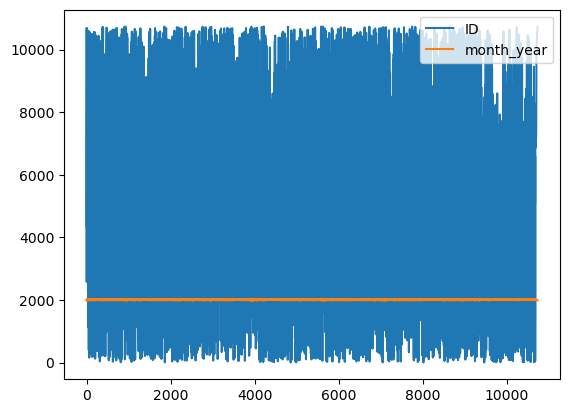

In [8]:
import matplotlib.pyplot as plt

data.plot()
plt.show()

In [13]:
import pandas as pd
import mysql.connector
import json

# Connect to MySQL
#Used the DSS_new for date matching
db = mysql.connector.connect(
        host=  "127.0.0.1",
        user= "root",
        password="Nanna&143",
        database="journals",
        auth_plugin='mysql_native_password')
    
cursor = db.cursor()
# Insert data into MySQL
for index, row in df.iterrows():
    standard_name=row["Standardized_Name"] if row['Standardized_Name'] else None
    # keywords = json.dumps(row['Keywords']) if row['Keywords'] else None  # Handle JSON
    # url=row["URL"] if row['URL'] else None
    # journal_title=row["Journal_Title"] if row['Journal_Title'] else None
    # volume_issue=row["Volume_Issue"] if row['Volume_Issue'] else None
    # month_year=row["Month_Year"] if row['Month_Year'] else None
    # abstract=row["Abstract"] if row['Abstract'] else None
    author_name=row["Author_Name"] if row['Author_Name'] else None
    # author_email=row["Author_Email"] if row['Author_Email'] else None
    # author_address=row["Author_Address"] if row['Author_Address'] else None
    

    try:
        sql = """
        Update Journal_Articles
        set Standardized_Name=%s
        where author_name=%s;
        """
        values = (
            standard_name,author_name
        )
        
        cursor.execute(sql, values)
    except Exception as e:
        print(f"Error inserting data: {e}{row["URL"]}")
        break
# Commit & close connection
db.commit()
cursor.close()
db.close()

print("Data inserted successfully!")

Data inserted successfully!


In [9]:
#For the decision support systems titles
import pandas as pd
import mysql.connector
import json

#connect to mysql
db=mysql.connector.connect(
    host="127.0.0.1",
    user='root',
    password='Nanna&143',
    database='journals',
    auth_plugin='mysql_native_password'
)
cursor=db.cursor()
for index, row in df.iterrows():
    title = row["Title"] if row["Title"] else None
    url = row["URL"] if row["URL"] else None
    vol_year=row["Vol Issue Year"] if row["Vol Issue Year"] else None

    try:
        sql = """
        INSERT INTO DecisionSupportSystems
        (Title, URL, vol_issue_year)
        VALUES (%s, %s, %s)
        """
        values = (title, url, vol_year)
        cursor.execute(sql, values)
    except Exception as e:
        print(f"Error inserting data: {e} {row['Title']}")
        break

db.commit()
cursor.close()
db.close()


In [1]:
import mysql.connector
import pandas as pd

db = mysql.connector.connect(
        host=  "127.0.0.1",
        user= "root",
        password="Nanna&143",
        database="journals",
        auth_plugin='mysql_native_password')

# Define the SQL query
query = "SELECT * FROM Journal_Articles"

# Read data into a Pandas DataFrame
df = pd.read_sql(query, db)

# Export DataFrame to Excel
df.to_excel("Journal_Articles_new.xlsx", index=False, engine="openpyxl")

# Close the database connection
db.close()

print("Data exported successfully to Journal_Articles.xlsx")


/var/folders/pk/rsrc4d3x4vdgqzfqp8r7lw080000gn/T/ipykernel_99855/2316557836.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, db)


Data exported successfully to Journal_Articles.xlsx
